<a href="https://colab.research.google.com/github/ChDamodhar/Machine-Learning/blob/main/DecisionTrees%26RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [90]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Social_Network_Ads.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [91]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [92]:
df.dtypes

,0
User ID,int64
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


In [93]:
df.isnull().sum()


,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [94]:
X = df.iloc[:,2:4].values
y = df.iloc[:,-1].values

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [96]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [97]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(
    criterion = 'entropy',
  )
classifier.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [98]:
y_pred = classifier.predict(X_test)

In [99]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88        52
           1       0.78      0.75      0.76        28

    accuracy                           0.84        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.84      0.84      0.84        80



In [100]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8375


In [101]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[46,  6],
       [ 7, 21]])

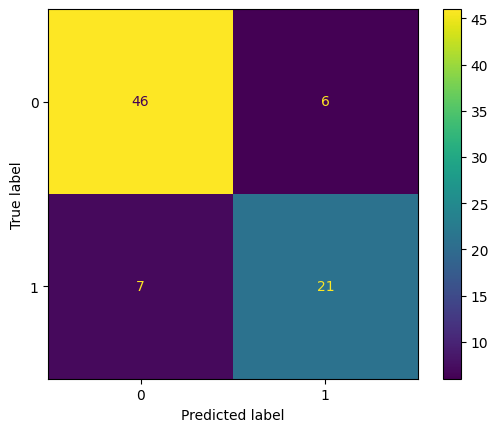

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

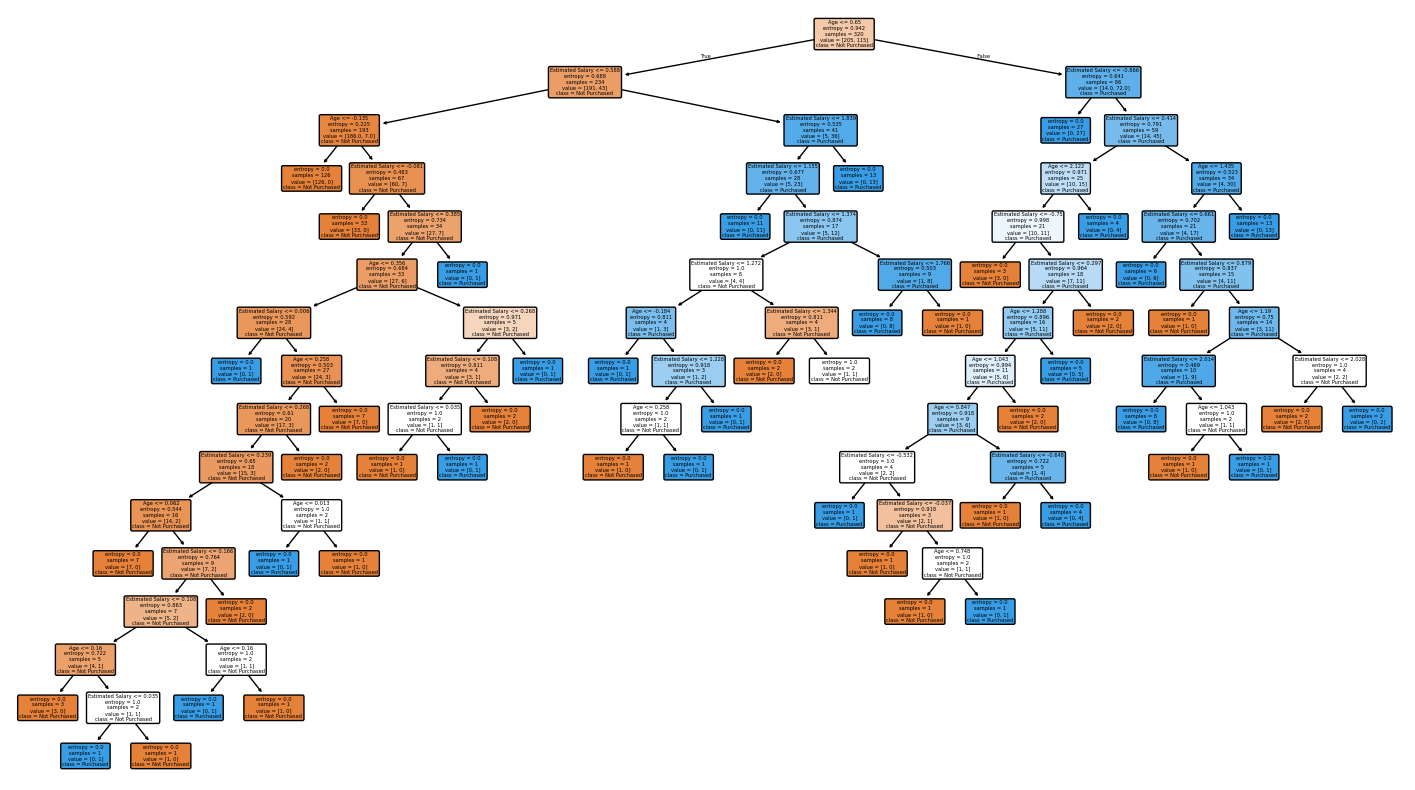

In [103]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(
    classifier,
    feature_names=['Age','Estimated Salary'],
    class_names=['Not Purchased','Purchased'],
    filled=True,
    rounded =True
)
plt.show()

# **Decision Tree Classifier - Titanic** **DataSet**

In [104]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


In [105]:
df=sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [106]:
df = df[['survived','pclass','sex','age','fare','embarked']]
df.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,male,22.0,7.2500,S
1,1,1,female,38.0,71.2833,C
2,1,3,female,26.0,7.9250,S
3,1,1,female,35.0,53.1000,S
4,0,3,male,35.0,8.0500,S


In [107]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
fare,0
embarked,2


In [108]:
df['age'].fillna(df['age'].median(),inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)

/tmp/ipython-input-3731520689.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(),inplace=True)
/tmp/ipython-input-3731520689.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

In [109]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
fare,0
embarked,0


In [110]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
fare,float64
embarked,object


In [111]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['sex'] = le.fit_transform(df['sex'])
df['embarked'] = le.fit_transform(df['embarked'])

In [112]:
df.head()

,survived,pclass,sex,age,fare,embarked
0,0,3,1,22.0,7.2500,2
1,1,1,0,38.0,71.2833,0
2,1,3,0,26.0,7.9250,2
3,1,1,0,35.0,53.1000,2
4,0,3,1,35.0,8.0500,2


In [113]:
X = df.drop('survived',axis=1)
y = df['survived']

X.head() , y.head()

(   pclass  sex   age     fare  embarked
 0       3    1  22.0   7.2500         2
 1       1    0  38.0  71.2833         0
 2       3    0  26.0   7.9250         2
 3       1    0  35.0  53.1000         2
 4       3    1  35.0   8.0500         2,
 0    0
 1    1
 2    1
 3    1
 4    0
 Name: survived, dtype: int64)

In [114]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [115]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [116]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(
    criterion = 'gini',
  )
classifier.fit(X_train, y_train)

DecisionTreeClassifier()

In [117]:
y_pred = classifier.predict(X_test)

In [118]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       105
           1       0.71      0.74      0.73        74

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.77       179
weighted avg       0.77      0.77      0.77       179



In [119]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.770949720670391


In [120]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[83, 22],
       [19, 55]])

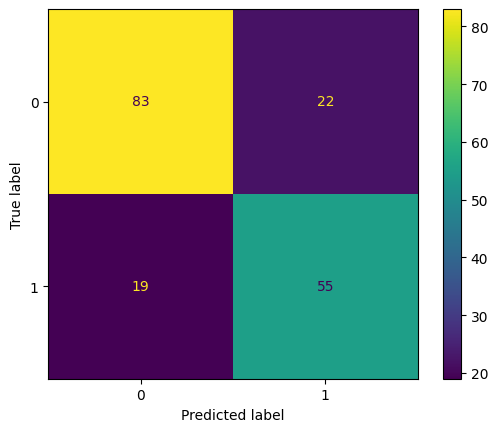

In [121]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

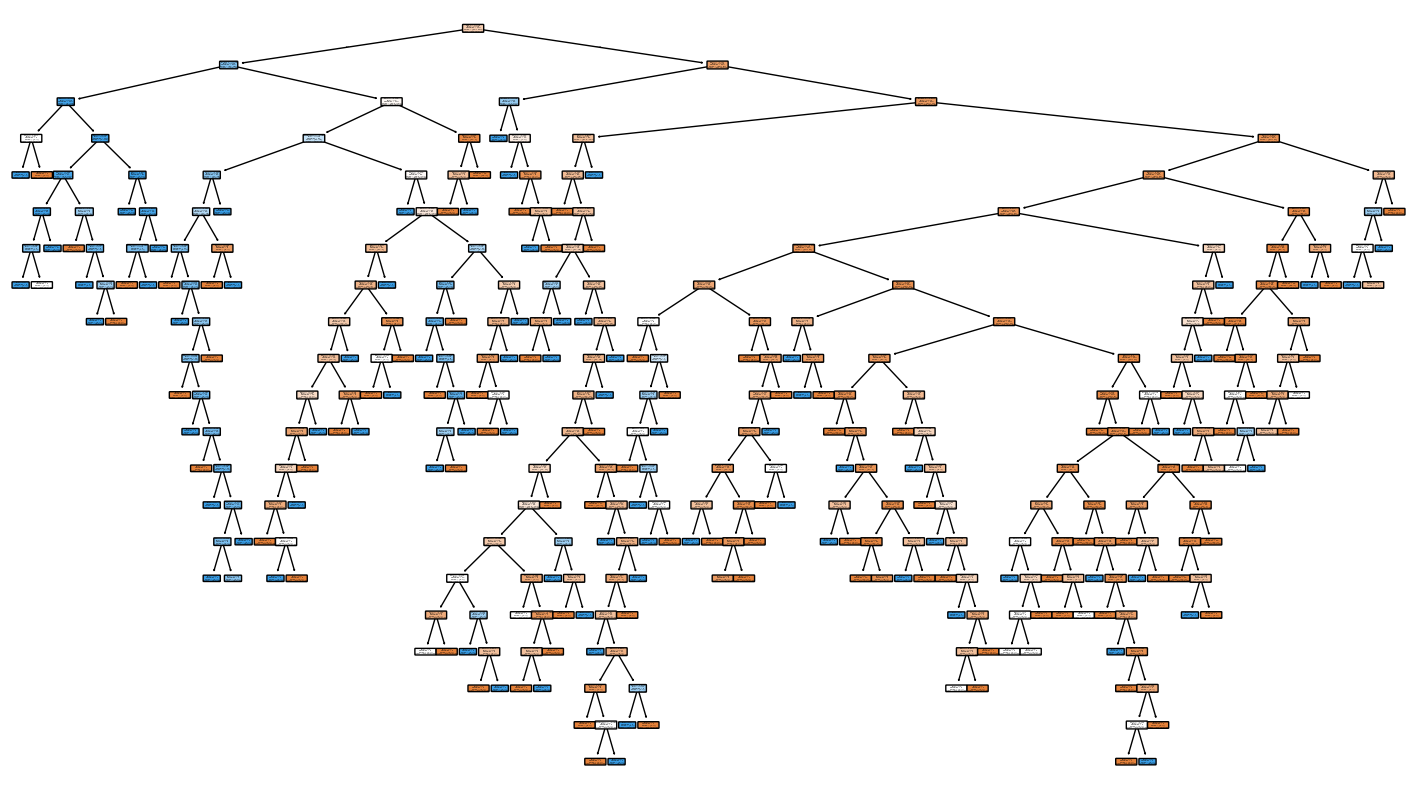

In [122]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(
    classifier,
    feature_names=['pclass','sex','age','fare','embarked'],
    class_names=['Not Survived','Survived'],
    filled=True,
    rounded =True
)
plt.show()

In [123]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(
    criterion = 'gini',
    max_depth = 4
  )
classifier.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [124]:
y_pred = classifier.predict(X_test)

In [125]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.7988826815642458


In [126]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[96,  9],
       [27, 47]])

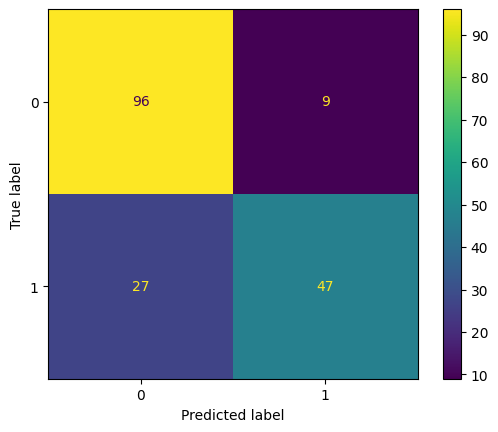

In [127]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

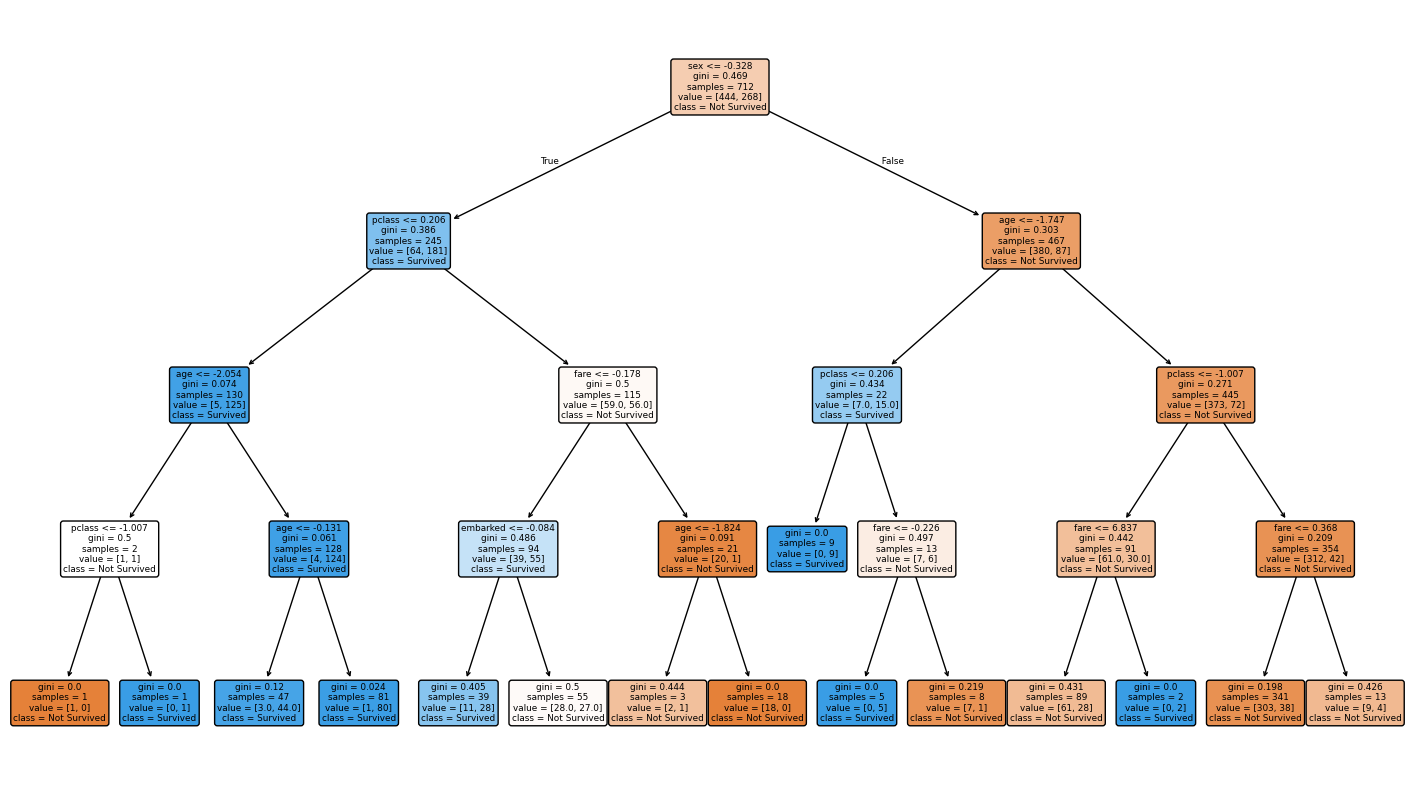

In [128]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))
plot_tree(
    classifier,
    feature_names=['pclass','sex','age','fare','embarked'],
    class_names=['Not Survived','Survived'],
    filled=True,
    rounded =True
)
plt.show()

In [129]:
new_passenger = pd.DataFrame([[3,1,25,7,2]],columns=['pclass','sex','age','fare','embarked'])
prediction = classifier.predict(new_passenger)
print(prediction)

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [130]:
if prediction[0]==1:
  print('Survived')
else:
  print('Not Survived')

Not Survived


Bank marketing Dataset

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


# **Bank Marketing dataset**

In [132]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/bank_marketing_dataset.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [133]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [134]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [135]:
df=df[['age','job','balance','loan','contact','deposit']]
df.head()

,age,job,balance,loan,contact,deposit
0,59,admin.,2343,no,unknown,yes
1,56,admin.,45,no,unknown,yes
2,41,technician,1270,no,unknown,yes
3,55,services,2476,no,unknown,yes
4,54,admin.,184,no,unknown,yes


In [136]:
X = df.drop('deposit', axis=1)
y = df['deposit']
X.head(), y.head()

(   age         job  balance loan  contact
 0   59      admin.     2343   no  unknown
 1   56      admin.       45   no  unknown
 2   41  technician     1270   no  unknown
 3   55    services     2476   no  unknown
 4   54      admin.      184   no  unknown,
 0    yes
 1    yes
 2    yes
 3    yes
 4    yes
 Name: deposit, dtype: object)

In [137]:
X = pd.get_dummies(X, drop_first=True)
X.head()

,age,balance,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,loan_yes,contact_telephone,contact_unknown
0,59,2343,False,False,False,False,False,False,False,False,False,False,False,False,False,True
1,56,45,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,41,1270,False,False,False,False,False,False,False,False,True,False,False,False,False,True
3,55,2476,False,False,False,False,False,False,True,False,False,False,False,False,False,True
4,54,184,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [138]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [139]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4
)

model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [140]:
y_pred = model.predict(X_test)


In [141]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.6547245857590686


In [142]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[736 430]
 [341 726]]

Classification Report:
              precision    recall  f1-score   support

          no       0.68      0.63      0.66      1166
         yes       0.63      0.68      0.65      1067

    accuracy                           0.65      2233
   macro avg       0.66      0.66      0.65      2233
weighted avg       0.66      0.65      0.65      2233



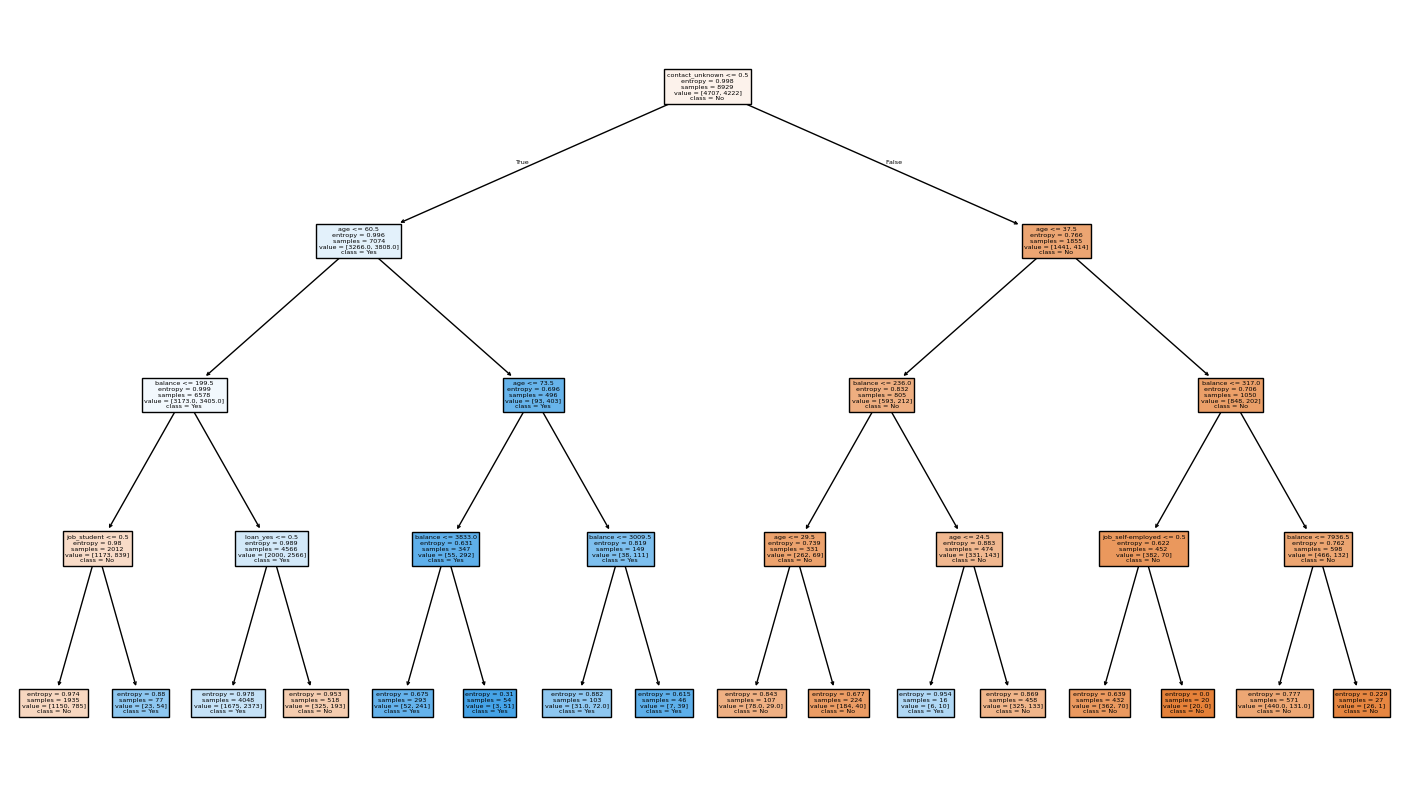

In [143]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)
plt.show()


In [144]:
new_customer = pd.DataFrame({
    'age': [35],
    'balance': [1500],
    'job': ['management'],
    'loan': ['no'],
    'contact': ['cellular']
})

# Encode to match training data
new_customer = pd.get_dummies(new_customer)
new_customer = new_customer.reindex(columns=X.columns, fill_value=0)

# Predict
prediction = model.predict(new_customer)

print(prediction)

# Decision message
if prediction[0] == 'yes':
    print("Likely to subscribe to the deposit")
else:
    print("Not likely to subscribe to the deposit")


['yes']
Likely to subscribe to the deposit


In [146]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns:", list(num_cols))


Numerical columns: ['age', 'balance']


In [147]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_count = ((df[col] < lower) | (df[col] > upper)).sum()
    percentage = (outlier_count / len(df)) * 100

    print(f"{col}: {outlier_count} outliers ({percentage:.2f}%)")


age: 171 outliers (1.53%)
balance: 1055 outliers (9.45%)


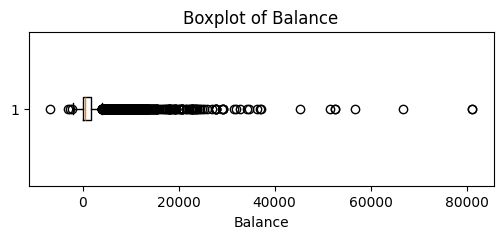

In [148]:
plt.figure(figsize=(6,2))
plt.boxplot(df['balance'], vert=False)
plt.title('Boxplot of Balance')
plt.xlabel('Balance')
plt.show()

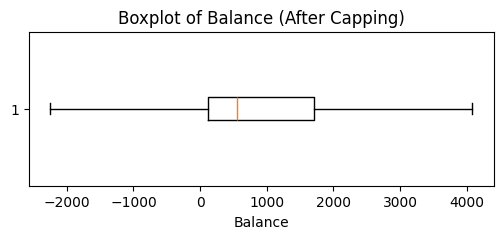

In [149]:
Q1 = df['balance'].quantile(0.25)
Q3 = df['balance'].quantile(0.75)
IQR = Q3 - Q1

lower_balance = Q1 - 1.5 * IQR
upper_balance = Q3 + 1.5 * IQR
df['balance'] = df['balance'].clip(lower_balance, upper_balance)
plt.figure(figsize=(6,2))
plt.boxplot(df['balance'], vert=False)
plt.title('Boxplot of Balance (After Capping)')
plt.xlabel('Balance')
plt.show()

In [153]:
# Select only the columns you want
X = df[['age', 'job', 'balance', 'loan', 'contact']]
y = df['deposit']
X.head(), y.head()

(   age         job  balance loan  contact
 0   59      admin.     2343   no  unknown
 1   56      admin.       45   no  unknown
 2   41  technician     1270   no  unknown
 3   55    services     2476   no  unknown
 4   54      admin.      184   no  unknown,
 0    yes
 1    yes
 2    yes
 3    yes
 4    yes
 Name: deposit, dtype: object)

In [156]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['job', 'loan', 'contact']
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])


/tmp/ipython-input-207417382.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipython-input-207417382.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = le.fit_transform(X[col])
/tmp/ipython-input-207417382.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/inde

In [157]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [158]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4
)

model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=4)

In [159]:
y_pred = model.predict(X_test)


In [160]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.658307210031348


In [161]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[717 449]
 [314 753]]

Classification Report:
              precision    recall  f1-score   support

          no       0.70      0.61      0.65      1166
         yes       0.63      0.71      0.66      1067

    accuracy                           0.66      2233
   macro avg       0.66      0.66      0.66      2233
weighted avg       0.66      0.66      0.66      2233



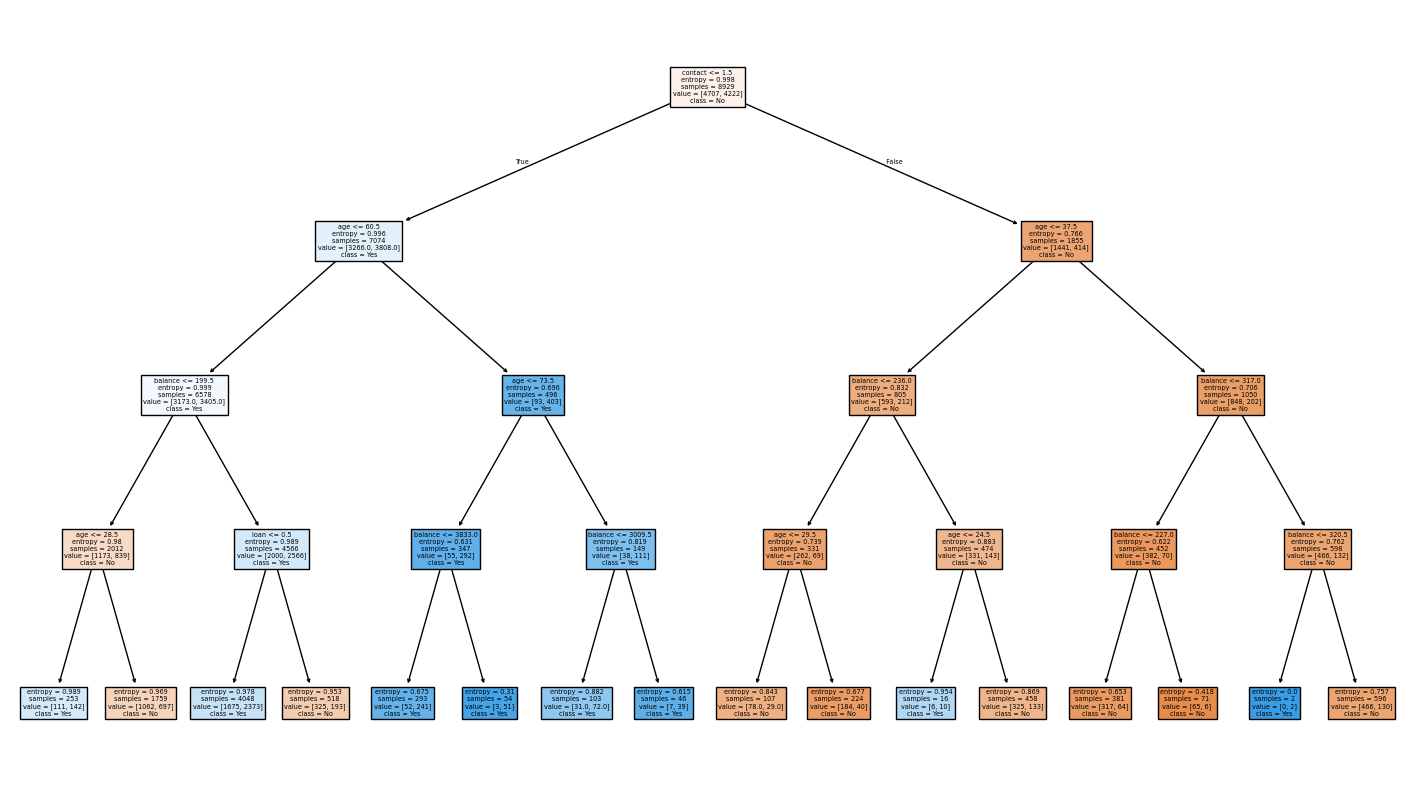

In [162]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No', 'Yes'],
    filled=True
)
plt.show()


# **RANDOM FOREST**

In [164]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Social_Network_Ads.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [166]:
df.dtypes

,0
User ID,int64
Gender,object
Age,int64
EstimatedSalary,int64
Purchased,int64


In [169]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [165]:
X = df.iloc[:,2:4].values
y = df.iloc[:,-1].values

In [167]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [168]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [170]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(
    n_estimators=10,
    criterion='entropy'
)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10)

In [171]:
y_pred = classifier.predict(X_test)

In [172]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.8875


In [173]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[47  5]
 [ 4 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.90      0.91        52
           1       0.83      0.86      0.84        28

    accuracy                           0.89        80
   macro avg       0.87      0.88      0.88        80
weighted avg       0.89      0.89      0.89        80



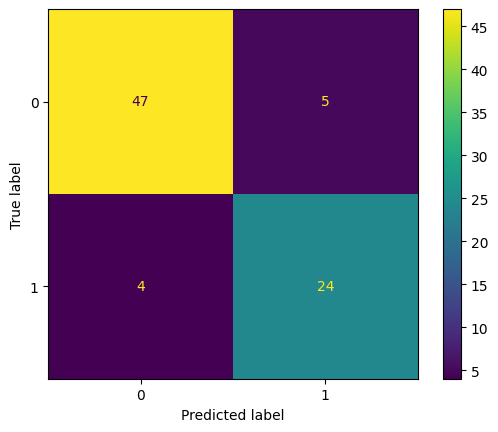

In [174]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

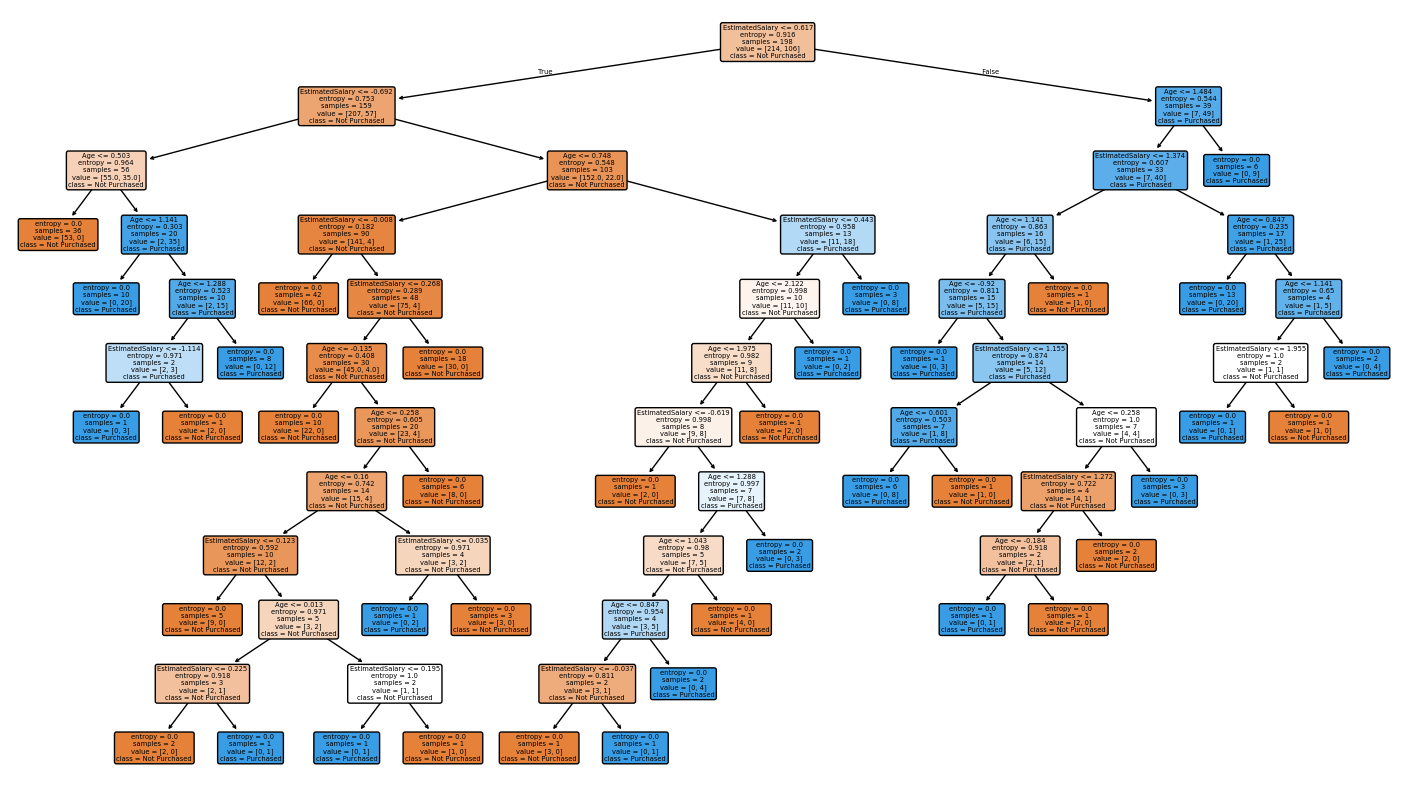

In [177]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    classifier.estimators_[0],
    filled=True,
    feature_names=['Age','EstimatedSalary'],
    class_names=['Not Purchased','Purchased'],
    rounded = True
)
plt.show()

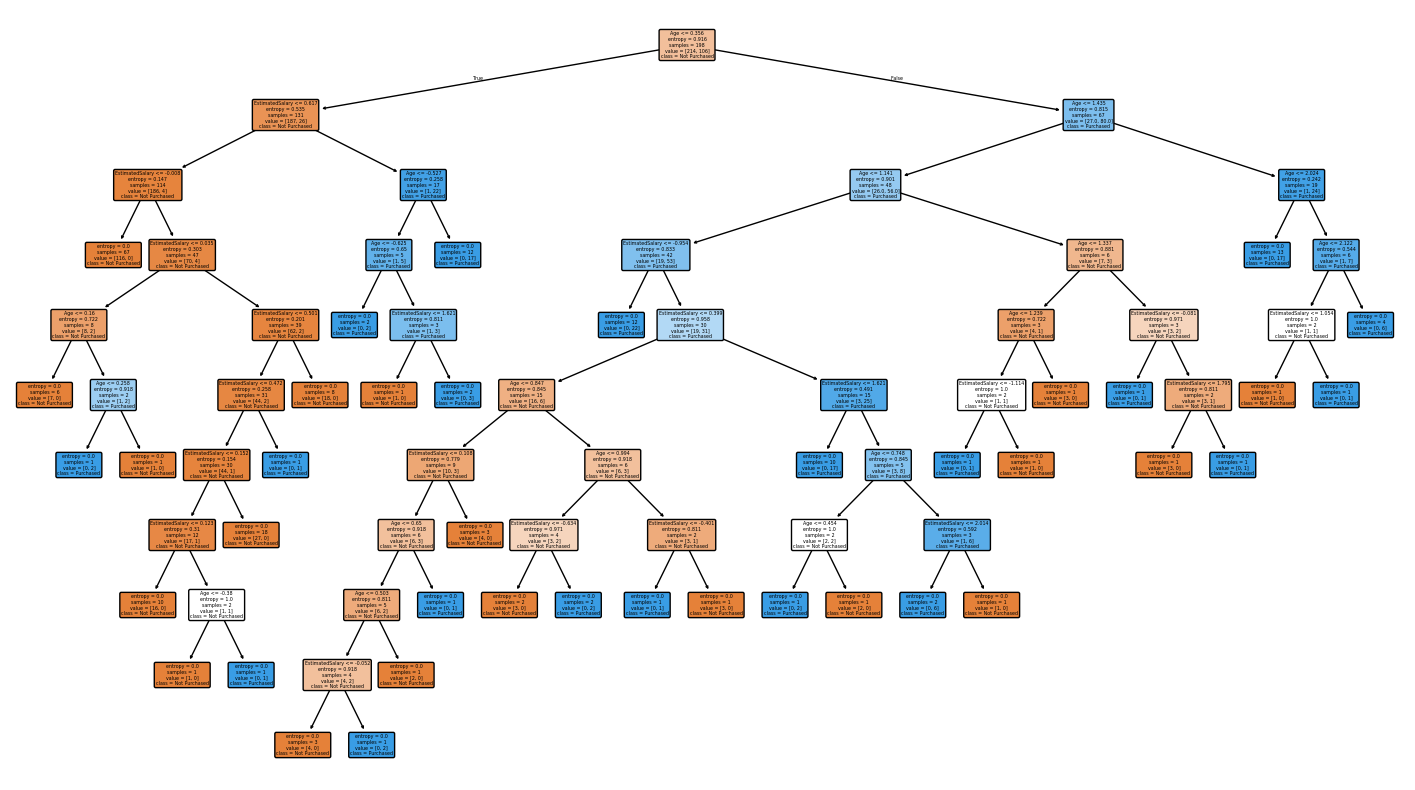

In [178]:
from sklearn.tree import plot_tree
plt.figure(figsize=(18,10))
plot_tree(
    classifier.estimators_[1],
    filled=True,
    feature_names=['Age','EstimatedSalary'],
    class_names=['Not Purchased','Purchased'],
    rounded = True
)
plt.show()

In [179]:
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/creditcard.csv')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [180]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [213]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [214]:
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_amount = df[(df['Amount'] < lower) | (df['Amount'] > upper)]

print("Number of Amount outliers:", outliers_amount.shape[0])
print("Percentage:", outliers_amount.shape[0] / len(df) * 100)


Number of Amount outliers: 31904
Percentage: 11.201971861646658


In [215]:
import numpy as np

df['Amount_log'] = np.log1p(df['Amount'])


In [216]:
X = df.drop('Class', axis=1)   # all columns except Class
y = df['Class']               # target


In [217]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [221]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='entropy',


)

dt_model.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy')

In [222]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = dt_model.predict(X_test)

dt_cm = confusion_matrix(y_test, y_pred)
print("Decision Tree Confusion Matrix:\n", dt_cm)
print(classification_report(y_test, y_pred))


Decision Tree Confusion Matrix:
 [[56841    23]
 [   16    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.78      0.84      0.81        98

    accuracy                           1.00     56962
   macro avg       0.89      0.92      0.90     56962
weighted avg       1.00      1.00      1.00     56962



In [223]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9993153330290369


In [192]:
TN, FP, FN, TP = dt_cm.ravel()

print("DT – Fraud correctly detected (TP):", TP)
print("DT – Legitimate incorrectly flagged (FP):", FP)


DT – Fraud correctly detected (TP): 81
DT – Legitimate incorrectly flagged (FP): 16


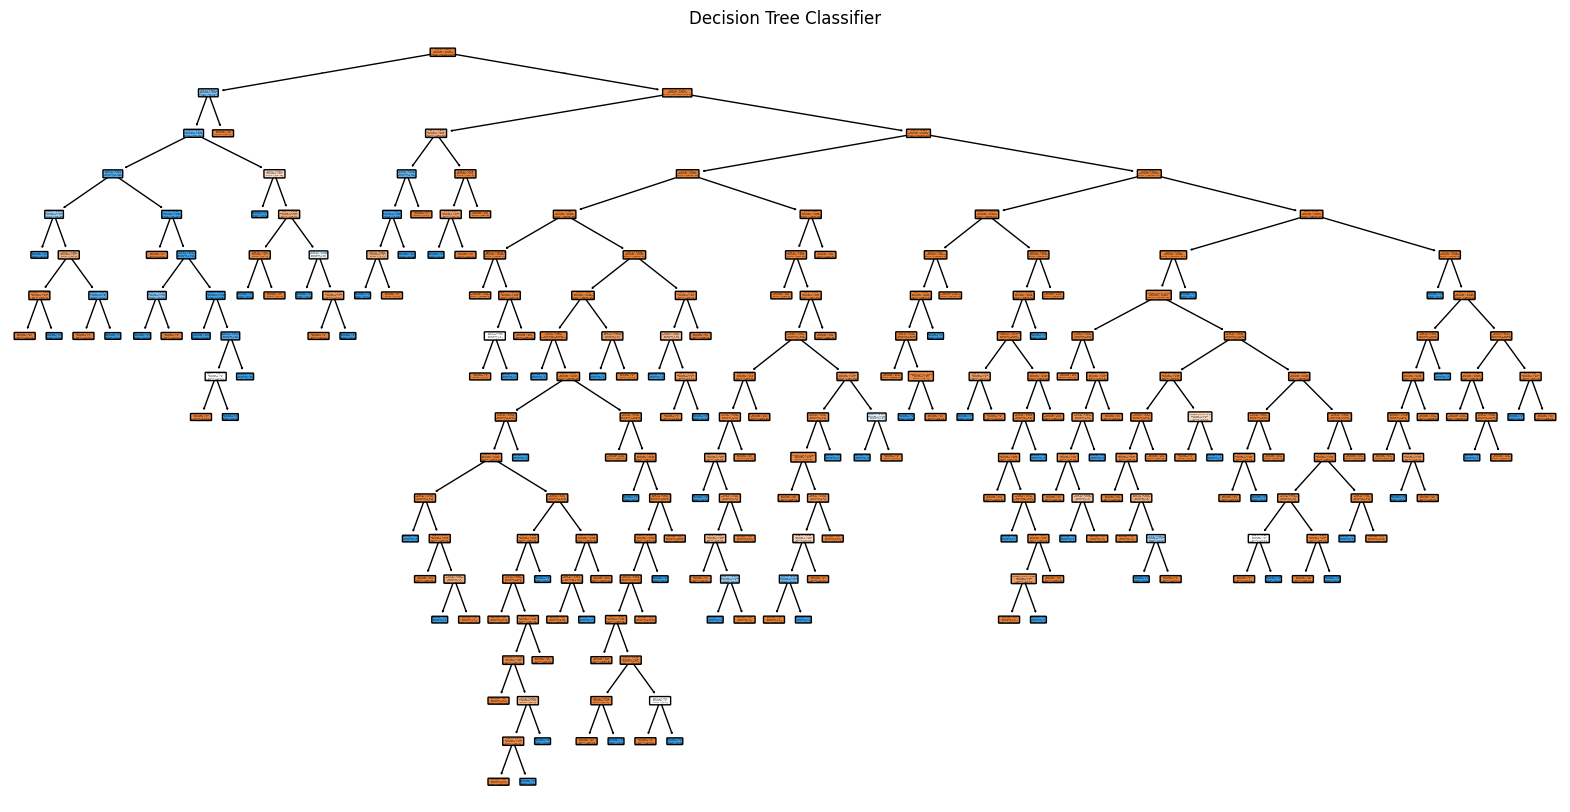

In [225]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=['Legitimate', 'Fraud'],
    rounded=True,

)
plt.title("Decision Tree Classifier")
plt.show()


Random Forest

In [227]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=25,
    criterion='entropy'
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(criterion='entropy', n_estimators=25)

In [228]:
rf_pred = rf_model.predict(X_test)

rf_cm = confusion_matrix(y_test, rf_pred)
print("Random Forest Confusion Matrix:\n", rf_cm)
print(classification_report(y_test, rf_pred))



Random Forest Confusion Matrix:
 [[56859     5]
 [   16    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.84      0.89        98

    accuracy                           1.00     56962
   macro avg       0.97      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962



In [229]:
from sklearn.metrics import confusion_matrix, accuracy_score
accuracy = accuracy_score(y_test, rf_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9996313331694814


In [230]:
TN, FP, FN, TP = rf_cm.ravel()

print("RF – Fraud correctly detected (TP):", TP)
print("RF – Legitimate incorrectly flagged (FP):", FP)


RF – Fraud correctly detected (TP): 82
RF – Legitimate incorrectly flagged (FP): 5


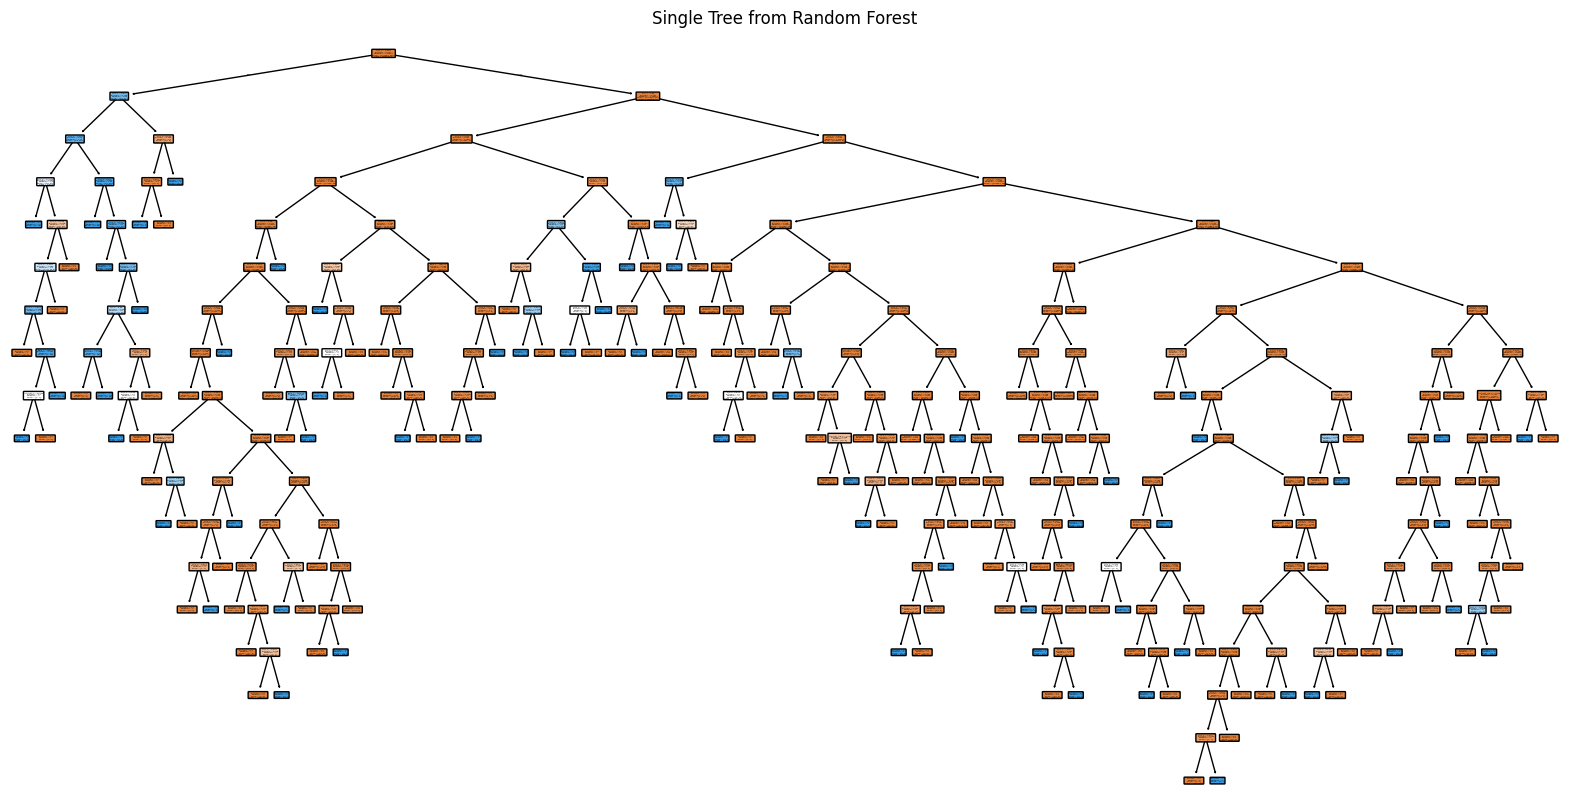

In [231]:
# Select one tree from the forest
estimator = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(
    estimator,
    filled=True,
    feature_names=X.columns,
    class_names=['Legitimate', 'Fraud'],
    rounded=True,

)
plt.title("Single Tree from Random Forest")
plt.show()


In [232]:
from sklearn.metrics import confusion_matrix

# Assuming y_test and y_pred (from your RF or DT model) are ready
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"Total Fraudulent Transactions in Test Set: {tp + fn}")
print(f"7a. Correcty Detected (True Positives): {tp}")
print(f"7b. Incorrectly Flagged Legitimate (False Positives): {fp}")
print(f"Missed Fraud (False Negatives): {fn}")

Total Fraudulent Transactions in Test Set: 98
7a. Correcty Detected (True Positives): 82
7b. Incorrectly Flagged Legitimate (False Positives): 23
Missed Fraud (False Negatives): 16


In [233]:
# 1. Define a simple rule: If Amount > 95th percentile, it's fraud
threshold = df['Amount'].quantile(0.95)
y_rule_pred = (X_test['Amount'] > threshold).astype(int)

# 2. Get metrics for the Rule-Based model
from sklearn.metrics import accuracy_score, recall_score
rule_accuracy = accuracy_score(y_test, y_rule_pred)
rule_recall = recall_score(y_test, y_rule_pred)

print(f"Rule-Based Accuracy: {rule_accuracy:.4f}")
print(f"Rule-Based Recall: {rule_recall:.4f}")

Rule-Based Accuracy: 0.9475
Rule-Based Recall: 0.0714


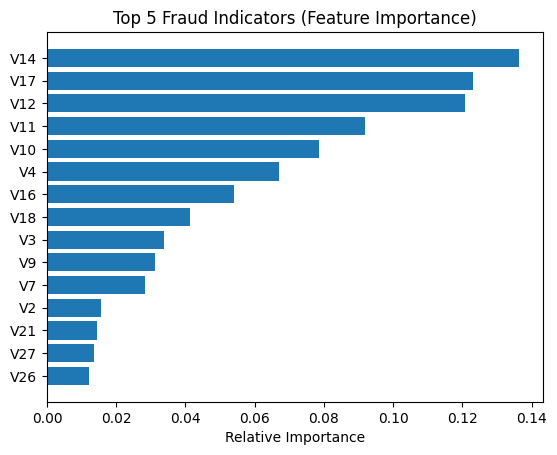

In [236]:
# Quick code to see what the bank should watch for
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-15:] # Top 5 features

plt.title('Top 5 Fraud Indicators (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()